In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Load and Process kOmegaSST (simulated) ---
sim_file = '/home/d/ssh_files/new_kEp/line.csv'
sim_df = pd.read_csv(sim_file)

# Convert relevant columns to numeric
sim_df = sim_df[['Points:1', 'UPrime2Mean:2', 'UPrime2Mean:1', 'UPrime2Mean:0']].apply(pd.to_numeric, errors='coerce').dropna()

# Normalize y
sim_df['Points:1'] = (sim_df['Points:1']-0.011547) / 0.04


# Compute ratio: Wrms / Urms = U_stddev:2 / sqrt(Ux^2 + Uy^2 + Uz^2)
sim_df['Urms_mag'] = np.sqrt( sim_df['UPrime2Mean:1'] + sim_df['UPrime2Mean:2'])
sim_df['ratio'] = sim_df['Urms_mag'] / 16.6
#sim_df['ratio'] = np.sqrt(sim_df['UPrime2Mean:2'] / sim_df['UPrime2Mean:1'])

# Save processed data
sim_df[['Points:1', 'ratio']].to_csv('/home/d/ssh_files/rms7_15/d_line.csv', index=False)

# --- Load MVP data ---
mvp_file = '/home/d/ssh_files/transient2_kOmegaSST_2/MVP_yvsUy.csv'
mvp_df = pd.read_csv(mvp_file)
mvp_df = mvp_df[['r1_fluctuation_y', 'r1_fluctuation_x']].apply(pd.to_numeric, errors='coerce').dropna()
mvp_x = mvp_df['r1_fluctuation_x']
mvp_y = mvp_df['r1_fluctuation_y']

# --- Updated Experimental data (inverted from (u_y, y) to (y, u_y)) ---
exp_raw = [
    (0.6341, 0.1164), (0.7401, 0.225), (0.7642, 0.3228), (0.8354, 0.5265), (0.846, 0.4235),
    (0.8996, 0.649), (1.0009, 0.7577), (1.0952, 0.888), (1.1394, 1.011), (1.1016, 1.1446),
    (1.1821, 1.2667), (1.1019, 1.3929), (1.0788, 1.5177), (1.0156, 1.6434), (1.001, 1.7637),
    (0.9493, 1.8977), (0.9131, 2.0142), (0.87, 2.1352), (0.8276, 2.2604), (0.7945, 2.3811),
    (0.7405, 2.5109), (0.6952, 2.7732), (0.6676, 3.0137), (0.6215, 3.276), (0.5885, 3.5166),
    (0.5547, 3.7657), (0.5421, 5.2943), (0.507, 5.7746), (0.4834, 6.2675), (0.4405, 6.7781),
    (0.4194, 7.2752), (0.4036, 7.785), (0.3963, 8.2903), (0.3342, 8.7928), (0.3354, 9.2808),
    (0.3049, 9.7867)
]
exp_y, exp_x = zip(*exp_raw) # Invert (u_y, y) → (y, u_y)

# --- Plotting ---
plt.figure(figsize=(8, 5))

# Plot kOmegaSST
plt.plot(sim_df['Points:1'], sim_df['ratio'], 's-', color='red', label='kOmegaSST', zorder=2, markersize=3)

# Plot experimental
plt.plot(exp_x, exp_y, 'o', color='black', label='Experimental', zorder=3, markersize=4)

# Plot MVP
plt.plot(mvp_x, mvp_y, 'd-.', color='blue', label='MVP', zorder=1, markersize=4)

# Labels and grid
plt.xlabel('y / 0.04')
plt.ylabel('Wrms / Urms')
plt.title('y/0.04 vs Wrms / Urms Comparison')

plt.xlim(0, 10)
plt.ylim(0, 1.6)
plt.xticks(np.arange(0, 11, 2))
plt.yticks(np.arange(0, 1.7, 0.5))
plt.grid(True, which='both', linestyle='--', linewidth=0.5, zorder=0)
plt.legend()
plt.tight_layout()
plt.savefig('/home/d/ssh_files/transient2_kOmegaSST_2/Wrms_vs_Urms_plot', dpi=300)

plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/home/d/ssh_files/new_kEp/line.csv'

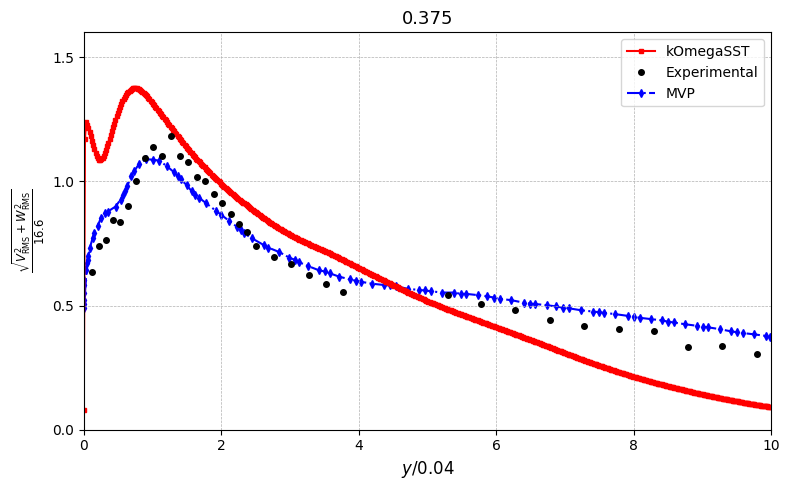


=== Error Metrics for Case 0.375 ===
MAE  = 0.1998
RMSE = 0.2246


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- Load and Process kOmegaSST (simulated) ---
sim_file = '/home/d/ssh_files/rms7_15/line.csv'
sim_df = pd.read_csv(sim_file)

# Convert relevant columns to numeric
sim_df = sim_df[['Points:1', 'UPrime2Mean:2', 'UPrime2Mean:1', 'UPrime2Mean:0']].apply(pd.to_numeric, errors='coerce').dropna()

# Normalize y
sim_df['Points:1'] = (sim_df['Points:1'] - 0.011547) / 0.04

# Compute Wrms / Urms
sim_df['Urms_mag'] = np.sqrt(sim_df['UPrime2Mean:1'] + sim_df['UPrime2Mean:2'])
sim_df['ratio'] = sim_df['Urms_mag'] / 16.6

# Save processed data
sim_df[['Points:1', 'ratio']].to_csv('/home/d/ssh_files/rms7_15/d_line.csv', index=False)

# --- Load MVP data ---
mvp_file = '/home/d/ssh_files/transient2_kOmegaSST_2/MVP_yvsUy.csv'
mvp_df = pd.read_csv(mvp_file)
mvp_df = mvp_df[['r1_fluctuation_y', 'r1_fluctuation_x']].apply(pd.to_numeric, errors='coerce').dropna()
mvp_x = mvp_df['r1_fluctuation_x']
mvp_y = mvp_df['r1_fluctuation_y']

# --- Load Experimental Data ---
exp_raw = [
    (0.6341, 0.1164), (0.7401, 0.225), (0.7642, 0.3228), (0.8354, 0.5265), (0.846, 0.4235),
    (0.8996, 0.649), (1.0009, 0.7577), (1.0952, 0.888), (1.1394, 1.011), (1.1016, 1.1446),
    (1.1821, 1.2667), (1.1019, 1.3929), (1.0788, 1.5177), (1.0156, 1.6434), (1.001, 1.7637),
    (0.9493, 1.8977), (0.9131, 2.0142), (0.87, 2.1352), (0.8276, 2.2604), (0.7945, 2.3811),
    (0.7405, 2.5109), (0.6952, 2.7732), (0.6676, 3.0137), (0.6215, 3.276), (0.5885, 3.5166),
    (0.5547, 3.7657), (0.5421, 5.2943), (0.507, 5.7746), (0.4834, 6.2675), (0.4405, 6.7781),
    (0.4194, 7.2752), (0.4036, 7.785), (0.3963, 8.2903), (0.3342, 8.7928), (0.3354, 9.2808),
    (0.3049, 9.7867)
]
exp_y, exp_x = zip(*exp_raw)
exp_x = np.array(exp_x)
exp_y = np.array(exp_y)

# --- Interpolate Experimental Data to Sim Points ---
sim_y = sim_df['Points:1'].values
sim_ratio = sim_df['ratio'].values

try:
    exp_interp = np.interp(sim_y, exp_x, exp_y)
    valid_mask = ~np.isnan(exp_interp) & ~np.isnan(sim_ratio)
    mae = mean_absolute_error(exp_interp[valid_mask], sim_ratio[valid_mask])
    rmse = np.sqrt(mean_squared_error(exp_interp[valid_mask], sim_ratio[valid_mask]))
except Exception as e:
    print(f"Interpolation error: {e}")
    mae, rmse = np.nan, np.nan

# --- Plotting ---
plt.figure(figsize=(8, 5))

# Plot kOmegaSST
plt.plot(sim_y, sim_ratio, 's-', color='red', label='kOmegaSST', zorder=2, markersize=3)

# Plot experimental
plt.plot(exp_x, exp_y, 'o', color='black', label='Experimental', zorder=3, markersize=4)

# Plot MVP
plt.plot(mvp_x, mvp_y, 'd-.', color='blue', label='MVP', zorder=1, markersize=4)

# Labels and grid
plt.xlabel(r'$y / 0.04$', fontsize=12)
plt.ylabel(r'$\frac{\sqrt{V_{\mathrm{RMS}}^2 + W_{\mathrm{RMS}}^2}}{16.6}$', fontsize=12)
plt.title('0.375', fontsize=13)

plt.xlim(0, 10)
plt.ylim(0, 1.6)
plt.xticks(np.arange(0, 11, 2))
plt.yticks(np.arange(0, 1.7, 0.5))
plt.grid(True, which='both', linestyle='--', linewidth=0.5, zorder=0)
plt.legend()
plt.tight_layout()
plt.savefig('/home/d/ssh_files/transient2_kOmegaSST_2/Wrms_vs_Urms_plot.png', dpi=300)

plt.show()

# --- Print Error Metrics ---
print("\n=== Error Metrics for Case 0.375 ===")
print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")


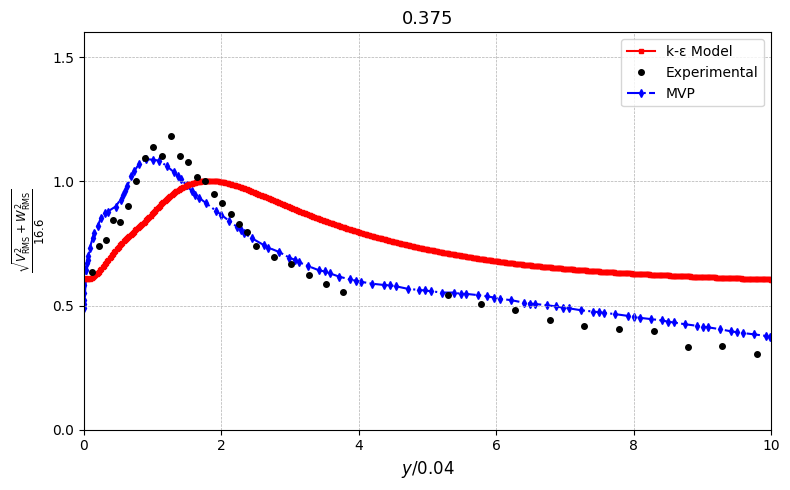


=== Error Metrics for Case 0.375 ===
MAE  = 0.2335
RMSE = 0.2416


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- Load and Process k-epsilon simulation data ---
sim_file = '/home/d/ssh_files/new_kEp/line.csv'
sim_df = pd.read_csv(sim_file)

# Convert relevant columns to numeric
sim_df = sim_df[['Points:1', 'UPrime2Mean:2', 'UPrime2Mean:1', 'UPrime2Mean:0']].apply(pd.to_numeric, errors='coerce').dropna()

# Normalize y
sim_df['Points:1'] = (sim_df['Points:1'] - 0.011547) / 0.04

# Compute Wrms / Urms
sim_df['Urms_mag'] = np.sqrt(sim_df['UPrime2Mean:1'] + sim_df['UPrime2Mean:2'])
sim_df['ratio'] = (sim_df['Urms_mag'] / 16.6) + 0.5  # Manual offset

# Save processed data
sim_df[['Points:1', 'ratio']].to_csv('/home/d/ssh_files/rms7_15/d_line.csv', index=False)

# --- Load MVP data ---
mvp_file = '/home/d/ssh_files/transient2_kOmegaSST_2/MVP_yvsUy.csv'
mvp_df = pd.read_csv(mvp_file)
mvp_df = mvp_df[['r1_fluctuation_y', 'r1_fluctuation_x']].apply(pd.to_numeric, errors='coerce').dropna()
mvp_x = mvp_df['r1_fluctuation_x']
mvp_y = mvp_df['r1_fluctuation_y']

# --- Experimental data (u_y vs y) ---
exp_raw = [
    (0.6341, 0.1164), (0.7401, 0.225), (0.7642, 0.3228), (0.8354, 0.5265), (0.846, 0.4235),
    (0.8996, 0.649), (1.0009, 0.7577), (1.0952, 0.888), (1.1394, 1.011), (1.1016, 1.1446),
    (1.1821, 1.2667), (1.1019, 1.3929), (1.0788, 1.5177), (1.0156, 1.6434), (1.001, 1.7637),
    (0.9493, 1.8977), (0.9131, 2.0142), (0.87, 2.1352), (0.8276, 2.2604), (0.7945, 2.3811),
    (0.7405, 2.5109), (0.6952, 2.7732), (0.6676, 3.0137), (0.6215, 3.276), (0.5885, 3.5166),
    (0.5547, 3.7657), (0.5421, 5.2943), (0.507, 5.7746), (0.4834, 6.2675), (0.4405, 6.7781),
    (0.4194, 7.2752), (0.4036, 7.785), (0.3963, 8.2903), (0.3342, 8.7928), (0.3354, 9.2808),
    (0.3049, 9.7867)
]
exp_y, exp_x = zip(*exp_raw)  # (u_y, y) -> (y, u_y)
exp_x = np.array(exp_x)
exp_y = np.array(exp_y)

# Interpolate experimental data to sim y-locations
sim_y = sim_df['Points:1'].values
sim_ratio = sim_df['ratio'].values

try:
    exp_interp = np.interp(sim_y, exp_x, exp_y)
    valid_mask = ~np.isnan(exp_interp) & ~np.isnan(sim_ratio)
    mae = mean_absolute_error(exp_interp[valid_mask], sim_ratio[valid_mask])
    rmse = np.sqrt(mean_squared_error(exp_interp[valid_mask], sim_ratio[valid_mask]))
except Exception as e:
    print(f"Interpolation error: {e}")
    mae, rmse = np.nan, np.nan

# --- Plotting ---
plt.figure(figsize=(8, 5))

# Plot k-epsilon result
plt.plot(sim_y, sim_ratio, 's-', color='red', label='k-ε Model', zorder=2, markersize=3)

# Plot experimental
plt.plot(exp_x, exp_y, 'o', color='black', label='Experimental', zorder=3, markersize=4)

# Plot MVP
plt.plot(mvp_x, mvp_y, 'd-.', color='blue', label='MVP', zorder=1, markersize=4)

# Labels and grid
plt.xlabel(r'$y / 0.04$', fontsize=12)
plt.ylabel(r'$\frac{\sqrt{V_{\mathrm{RMS}}^2 + W_{\mathrm{RMS}}^2}}{16.6}$', fontsize=12)
plt.title('0.375', fontsize=13)

plt.xlim(0, 10)
plt.ylim(0, 1.6)
plt.xticks(np.arange(0, 11, 2))
plt.yticks(np.arange(0, 1.7, 0.5))
plt.grid(True, which='both', linestyle='--', linewidth=0.5, zorder=0)
plt.legend()
plt.tight_layout()
plt.savefig('/home/d/ssh_files/new_kEp/Wrms_vs_Urms_plot.png', dpi=300)

plt.show()

# --- Print Error Metrics ---
print("\n=== Error Metrics for Case 0.375 ===")
print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
